# Práctica 02. Análisis Estadístico de señales — Parte 2

### Valentina García Obando Cc 1000539432
###  Mariana Giraldo Gil  Cc 1062424194

## Acercamiento a la base de datos de arritmias cardiacas y comparación estadística

## Resumen del trabajo realizado

Este notebook desarrolla la segunda parte de la Práctica 2, centrada en el acercamiento a una base de datos pública de señales ECG de 12 derivaciones con diagnóstico de arritmias: la base **ChapmanECG** (Chapman University y Shaoxing People's Hospital), disponible en [figshare](https://figshare.com/collections/ChapmanECG/4560497).

Se realiza primero una exploración general de la base de datos (número de sujetos, tipos de ritmos disponibles, canales, frecuencia de muestreo y duración de los registros). Luego se seleccionan dos tipos de arritmia para visualizar y caracterizar morfológicamente sus señales ECG. Finalmente, se realiza un análisis estadístico comparativo entre los dos grupos de arritmias seleccionados, verificando los supuestos de normalidad y homocedasticidad antes de aplicar la prueba paramétrica o no paramétrica correspondiente, y se interpretan los resultados en el contexto clínico de las señales ECG.

### Sobre la base de datos

La base ChapmanECG fue publicada por Zheng et al. (2020, *Scientific Data*) y contiene registros de ECG de 12 derivaciones de **10 646 pacientes**, adquiridos con el sistema GE MUSE en el Shaoxing People's Hospital. Cada registro corresponde a un examen de reposo de **10 segundos** muestreado a **500 Hz** (5000 muestras por derivación), con las 12 derivaciones estándar: I, II, III, aVR, aVL, aVF, V1–V6. Cada paciente fue diagnosticado por cardiólogos con uno de **11 ritmos cardiacos** posibles, además de otras condiciones cardiovasculares adicionales.

Los archivos relevantes para este trabajo son:
- **`Diagnostics.xlsx`**: hoja de cálculo con una fila por paciente, que incluye el nombre del archivo (`FileName`), el ritmo diagnosticado (`Rhythm`), edad, género, frecuencia cardiaca (`VentricularRate`), duración del QRS, entre otras variables.
- **`ConditionNames.xlsx`**: tabla de equivalencia entre las siglas de las condiciones cardiovasculares adicionales (columna `Beat`) y su nombre completo. Los nombres de los 11 ritmos (columna `Rhythm`) se toman de la documentación de la base (Zheng et al., 2020).
- **`ECGDataDenoised.zip`**: carpeta con un archivo `.csv` por paciente (5000 filas x 12 columnas, una por derivación, en el mismo orden mencionado arriba), correspondiente a la señal ya filtrada/denoised.

### Descarga y organización de los datos

Antes de ejecutar este notebook es necesario:

1. Ir a la colección de figshare: https://figshare.com/collections/ChapmanECG/4560497
2. Descargar `Diagnostics.xlsx`, `ConditionNames.xlsx` y `ECGDataDenoised.zip`.
3. Descomprimir `ECGDataDenoised.zip` (queda una carpeta `ECGDataDenoised/` con miles de archivos `.csv`, uno por paciente).
4. Colocar los tres elementos dentro de una carpeta de trabajo (por ejemplo `./ChapmanECG/`) con la siguiente estructura, y ajustar `RUTA_BASE` en la celda de configuración si se usa otra ubicación:

```
ChapmanECG/
├── Diagnostics.xlsx
├── ConditionNames.xlsx
└── ECGDataDenoised/
    ├── MUSE_20180111_...csv
    ├── MUSE_20180112_...csv
    └── ...
```

**Nota:** el archivo `ECGDataDenoised.zip` pesa varios GB (>10 000 registros), por lo que la descarga y descompresión pueden tardar varios minutos. Si se trabaja en Google Colab, se recomienda montar Google Drive y guardar allí los datos descomprimidos para no perderlos al reiniciar el entorno.

In [1]:
# Instalación de librerías necesarias (descomentar si hace falta en el entorno)
# !pip install pandas numpy matplotlib scipy statsmodels openpyxl seaborn
%pip install openpyxl seaborn scipy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks, butter, filtfilt
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, probplot, spearmanr
from IPython.display import display

sns.set_style("whitegrid")

# Orden estándar de las 12 derivaciones tal como se almacenan en cada .csv
DERIVACIONES = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
FS = 500  # Hz, frecuencia de muestreo de la base ChapmanECG

## 1. Exploración y descripción de la base de datos

In [3]:
# Ruta base donde se ubican Diagnostics.xlsx, ConditionNames.xlsx y la carpeta ECGDataDenoised/
RUTA_BASE = "./ChapmanECG"

ruta_diagnosticos = os.path.join(RUTA_BASE, "Diagnostics.xlsx")
ruta_nombres = os.path.join(RUTA_BASE, "ConditionNames.xlsx")
ruta_señales = os.path.join(RUTA_BASE, "ECGDataDenoised")

if not os.path.exists(ruta_diagnosticos):
    print("No se encontró Diagnostics.xlsx en", RUTA_BASE)
    print("Descargue los archivos de https://figshare.com/collections/ChapmanECG/4560497")
    print("y ajuste la variable RUTA_BASE antes de continuar.")
else:
    diagnosticos = pd.read_excel(ruta_diagnosticos)
    print("Diagnostics.xlsx cargado correctamente")
    print("Número de registros:", diagnosticos.shape[0])
    print("Columnas disponibles:", list(diagnosticos.columns))
    display(diagnosticos.head())

    # Tabla de equivalencia sigla -> nombre completo
    nombres_condiciones = pd.read_excel(ruta_nombres)
    display(nombres_condiciones.head(15))

Diagnostics.xlsx cargado correctamente
Número de registros: 10646
Columnas disponibles: ['FileName', 'Rhythm', 'Beat', 'PatientAge', 'Gender', 'VentricularRate', 'AtrialRate', 'QRSDuration', 'QTInterval', 'QTCorrected', 'RAxis', 'TAxis', 'QRSCount', 'QOnset', 'QOffset', 'TOffset']


,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354


,Acronym Name,Full Name
0,1AVB,1 degree atrioventricular block
1,2AVB,2 degree atrioventricular block
2,2AVB1,2 degree atrioventricular block(Type one)
3,2AVB2,2 degree atrioventricular block(Type two)
4,3AVB,3 degree atrioventricular block
5,ABI,atrial bigeminy
6,ALS,Axis left shift
7,APB,atrial premature beats
8,AQW,abnormal Q wave
9,ARS,Axis right shift


In [4]:
# Distribución de sujetos por tipo de ritmo cardiaco
conteo_ritmos = diagnosticos["Rhythm"].value_counts()
tabla_ritmos = conteo_ritmos.rename_axis("Ritmo").reset_index(name="Sujetos")
tabla_ritmos["Porcentaje (%)"] = (tabla_ritmos["Sujetos"] / tabla_ritmos["Sujetos"].sum() * 100).round(2)

# Nombre completo de cada ritmo (documentación de la base, Zheng et al., 2020).
# ConditionNames.xlsx contiene las siglas de la columna Beat, no las de los ritmos.
nombres_ritmos = {
    "SB": "Sinus Bradycardia (bradicardia sinusal)",
    "SR": "Sinus Rhythm (ritmo sinusal normal)",
    "AFIB": "Atrial Fibrillation (fibrilación auricular)",
    "ST": "Sinus Tachycardia (taquicardia sinusal)",
    "SVT": "Supraventricular Tachycardia (taquicardia supraventricular)",
    "AF": "Atrial Flutter (aleteo auricular)",
    "SA": "Sinus Irregularity (irregularidad sinusal)",
    "AT": "Atrial Tachycardia (taquicardia auricular)",
    "AVNRT": "AV Node Reentrant Tachycardia",
    "AVRT": "AV Reentrant Tachycardia",
    "SAAWR": "Sinus Atrium to Atrial Wandering Rhythm",
}
tabla_ritmos.insert(1, "Nombre completo", tabla_ritmos["Ritmo"].map(nombres_ritmos))
tabla_ritmos

,Ritmo,Nombre completo,Sujetos,Porcentaje (%)
0,SB,Sinus Bradycardia (bradicardia sinusal),3889,36.53
1,SR,Sinus Rhythm (ritmo sinusal normal),1826,17.15
2,AFIB,Atrial Fibrillation (fibrilación auricular),1780,16.72
3,ST,Sinus Tachycardia (taquicardia sinusal),1568,14.73
4,SVT,Supraventricular Tachycardia (taquicardia supr...,587,5.51
5,AF,Atrial Flutter (aleteo auricular),445,4.18
6,SA,Sinus Irregularity (irregularidad sinusal),399,3.75
7,AT,Atrial Tachycardia (taquicardia auricular),121,1.14
8,AVNRT,AV Node Reentrant Tachycardia,16,0.15
9,AVRT,AV Reentrant Tachycardia,8,0.08


In [5]:
# Verificación empírica del formato de los registros (canales, muestras, duración)
archivo_ejemplo = diagnosticos["FileName"].iloc[0]
registro_ejemplo = pd.read_csv(os.path.join(ruta_señales, archivo_ejemplo + ".csv"), header=None)
n_muestras, n_canales = registro_ejemplo.shape
print("Archivo de ejemplo:", archivo_ejemplo)
print("Forma del registro (muestras x canales):", registro_ejemplo.shape)
print("Duración a", FS, "Hz:", n_muestras / FS, "s")
print("Archivos .csv disponibles en ECGDataDenoised:", len([f for f in os.listdir(ruta_señales) if f.endswith(".csv")]))

Archivo de ejemplo: MUSE_20180113_171327_27000
Forma del registro (muestras x canales): (5000, 12)
Duración a 500 Hz: 10.0 s
Archivos .csv disponibles en ECGDataDenoised: 10646


In [6]:
# Resumen demográfico (edad y género) por ritmo
resumen_demografico = diagnosticos.groupby("Rhythm").agg(
    Sujetos=("FileName", "count"),
    Edad_media=("PatientAge", "mean"),
    Edad_std=("PatientAge", "std"),
    Hombres_pct=("Gender", lambda g: (g == "MALE").mean() * 100),
).round(1).sort_values("Sujetos", ascending=False)
resumen_demografico

,Sujetos,Edad_media,Edad_std,Hombres_pct
Rhythm,,,,
SB,3889,58.3,14.0,63.8
SR,1826,54.4,16.3,43.9
AFIB,1780,73.4,11.1,58.5
ST,1568,54.6,21.1,51.0
SVT,587,55.6,18.5,47.5
AF,445,71.1,13.5,57.8
SA,399,34.7,23.0,55.9
AT,121,65.7,19.3,52.9
AVNRT,16,57.9,17.3,25.0


**Número total de registros y sujetos:** la base contiene **10 646 pacientes**, cada uno con un único registro ECG de 12 derivaciones (un archivo `.csv` por paciente), por lo que el número de registros coincide con el número de sujetos.

**Tipos de arritmias o clases disponibles:** el campo `Rhythm` codifica **11 ritmos cardiacos** distintos, resumidos en la siguiente tabla, que coincide con la generada por el código a partir de `Diagnostics.xlsx`:

| Ritmo | Sigla | Sujetos | % |
|---|---|---|---|
| Sinus Bradycardia (bradicardia sinusal) | SB | 3 889 | 36.53 |
| Sinus Rhythm (ritmo sinusal normal) | SR | 1 826 | 17.15 |
| Atrial Fibrillation (fibrilación auricular) | AFIB | 1 780 | 16.72 |
| Sinus Tachycardia (taquicardia sinusal) | ST | 1 568 | 14.73 |
| Supraventricular Tachycardia | SVT | 587 | 5.51 |
| Atrial Flutter (aleteo auricular) | AF | 445 | 4.18 |
| Sinus Irregularity (irregularidad sinusal) | SA | 399 | 3.75 |
| Atrial Tachycardia | AT | 121 | 1.14 |
| AV Node Reentrant Tachycardia | AVNRT | 16 | 0.15 |
| AV Reentrant Tachycardia | AVRT | 8 | 0.08 |
| Sinus to Atrial Wandering Rhythm | SAAWR | 7 | 0.07 |
| **Total** | | **10 646** | **100** |

Se observa que la distribución de clases es muy desbalanceada: la bradicardia sinusal (SB) y el ritmo sinusal normal (SR) concentran más de la mitad de los sujetos, mientras que ritmos como AVNRT, AVRT y SAAWR apenas suman unas pocas decenas de casos. Esto es relevante porque cualquier análisis estadístico o de clasificación posterior debe considerar este desbalance (por ejemplo, tomando muestras de tamaño comparable entre grupos al comparar dos arritmias, en lugar de usar el grupo completo).

**Número de canales y derivaciones:** cada registro tiene **12 canales**, correspondientes a las derivaciones estándar del ECG: I, II, III (derivaciones de miembros), aVR, aVL, aVF (derivaciones aumentadas) y V1–V6 (derivaciones precordiales).

**Frecuencia de muestreo y duración:** todos los registros se adquirieron a **500 Hz** durante **10 segundos**, es decir, 5000 muestras por derivación y por paciente. Esto se verificó directamente sobre los archivos: cada `.csv` tiene forma (5000, 12) y la carpeta contiene 10 646 archivos, uno por paciente.

**Características demográficas:** la edad media varía entre ritmos; los pacientes con AFIB (73.4 ± 11.1 años) y AF (71.1 ± 13.5 años) son en promedio los de mayor edad, mientras que los de irregularidad sinusal SA son los más jóvenes (34.7 ± 23.0 años). En SB predominan los hombres (63.8 %).

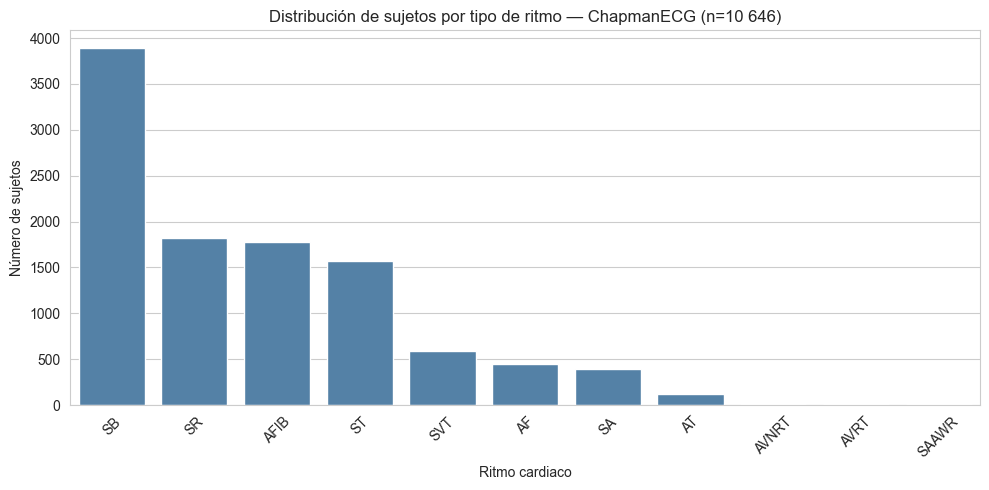

In [7]:
# Gráfico de barras con la distribución de sujetos por ritmo
plt.figure(figsize=(10,5))
sns.barplot(x=tabla_ritmos["Ritmo"], y=tabla_ritmos["Sujetos"], color="steelblue")
plt.ylabel("Número de sujetos")
plt.xlabel("Ritmo cardiaco")
plt.title("Distribución de sujetos por tipo de ritmo — ChapmanECG (n=10 646)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


La gráfica confirma visualmente el fuerte desbalance entre clases: SB, SR, AFIB y ST agrupan a la gran mayoría de los pacientes, mientras que las cinco últimas categorías (SI, AT, AVNRT, AVRT, SAAWR) representan en conjunto menos del 6 % de la base. Para el análisis comparativo de la sección 3 se trabajará con dos de los grupos más numerosos, de forma que las pruebas estadísticas tengan suficiente tamaño de muestra.

## 2. Visualización y caracterización de las señales

Para esta actividad se seleccionaron dos ritmos con interpretación clínica claramente distinta y buen número de sujetos disponibles:

- **AFIB — Fibrilación auricular:** arritmia supraventricular caracterizada por una actividad auricular caótica y desorganizada (ausencia de onda P definida) y por un ritmo ventricular **irregularmente irregular**, es decir, sin un patrón predecible entre latidos consecutivos.
- **SB — Bradicardia sinusal:** el ritmo se origina en el nodo sinusal (por lo que conserva onda P y complejo QRS normales), pero con una frecuencia cardiaca por debajo de 60 lpm; el ritmo es regular, solo que más lento de lo habitual.

Se espera entonces que la señal de AFIB muestre irregularidad en los intervalos entre picos R (RR) y ausencia de onda P, mientras que la señal de SB debería verse como un ECG normal pero con ciclos cardiacos más espaciados en el tiempo.

In [8]:
# Selección de un registro de cada ritmo a partir de Diagnostics.xlsx
archivo_afib = diagnosticos.loc[diagnosticos["Rhythm"] == "AFIB", "FileName"].sample(1, random_state=42).values[0]
archivo_sb   = diagnosticos.loc[diagnosticos["Rhythm"] == "SB",   "FileName"].sample(1, random_state=42).values[0]

print("Registro AFIB seleccionado:", archivo_afib)
print("Registro SB seleccionado:", archivo_sb)

def cargar_registro(nombre_archivo, derivacion="II"):
    ruta = os.path.join(ruta_señales, nombre_archivo + ".csv")
    señal = pd.read_csv(ruta, header=None)
    señal.columns = DERIVACIONES
    t = np.arange(señal.shape[0]) / FS
    return t, señal[derivacion].values

t_afib, ecg_afib = cargar_registro(archivo_afib, derivacion="II")
t_sb, ecg_sb   = cargar_registro(archivo_sb, derivacion="II")

Registro AFIB seleccionado: MUSE_20180114_135033_25000
Registro SB seleccionado: MUSE_20180116_124254_79000


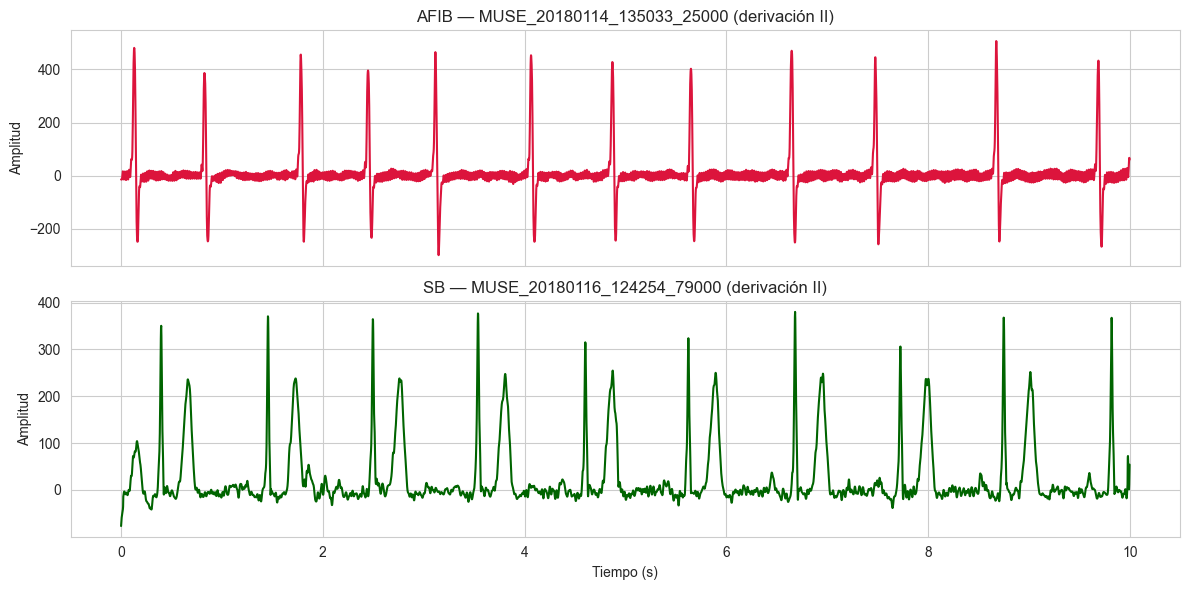

In [9]:
# Visualización comparativa de las señales (derivación II)
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axs[0].plot(t_afib, ecg_afib, color="crimson")
axs[0].set_title(f"AFIB — {archivo_afib} (derivación II)")
axs[0].set_ylabel("Amplitud")

axs[1].plot(t_sb, ecg_sb, color="darkgreen")
axs[1].set_title(f"SB — {archivo_sb} (derivación II)")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Amplitud")

plt.tight_layout()
plt.show()


In [10]:
# Estimación de frecuencia cardiaca y regularidad a partir de los picos R
def detectar_picos_r(señal, fs=FS):
    # Detector tipo Pan-Tompkins:
    # 1) Filtro pasabanda 5-15 Hz: resalta el QRS y atenúa la onda T (más lenta) y el ruido
    x = np.asarray(señal, dtype=float)
    b, a = butter(2, [5, 15], btype="bandpass", fs=fs)
    filtrada = filtfilt(b, a, x)
    # 2) Derivada al cuadrado + integración en ventana de 120 ms (energía del QRS)
    ventana = int(0.12 * fs)
    energia = np.convolve(np.gradient(filtrada) ** 2, np.ones(ventana) / ventana, mode="same")
    # 3) Candidatos: picos de energía por encima del 30 % del nivel de los QRS, separados al menos 300 ms
    umbral = 0.3 * np.percentile(energia, 99)
    candidatos, _ = find_peaks(energia, height=umbral, distance=int(0.3 * fs))
    # 4) El pico R se ubica en el máximo absoluto de la señal (sin nivel DC) cerca de cada candidato
    x0 = x - np.median(x)
    w = int(0.06 * fs)
    picos = [max(c - w, 0) + np.argmax(np.abs(x0[max(c - w, 0):c + w])) for c in candidatos]
    return np.unique(np.array(picos, dtype=int))

picos_afib = detectar_picos_r(ecg_afib)
picos_sb   = detectar_picos_r(ecg_sb)

rr_afib = np.diff(picos_afib) / FS  # intervalos RR en segundos
rr_sb   = np.diff(picos_sb) / FS

fc_afib = 60 / rr_afib.mean() if len(rr_afib) > 0 else np.nan
fc_sb   = 60 / rr_sb.mean() if len(rr_sb) > 0 else np.nan

print("AFIB -> número de latidos detectados:", len(picos_afib))
print("AFIB -> intervalos RR (s):", np.round(rr_afib, 3))
print("AFIB -> frecuencia cardiaca promedio estimada:", round(fc_afib, 1), "lpm")
print("AFIB -> desviación estándar de los RR (variabilidad):", round(rr_afib.std(), 4), "s")
print("AFIB -> FC reportada en Diagnostics.xlsx:", diagnosticos.loc[diagnosticos.FileName == archivo_afib, "VentricularRate"].values[0], "lpm")
print()
print("SB -> número de latidos detectados:", len(picos_sb))
print("SB -> intervalos RR (s):", np.round(rr_sb, 3))
print("SB -> frecuencia cardiaca promedio estimada:", round(fc_sb, 1), "lpm")
print("SB -> desviación estándar de los RR (variabilidad):", round(rr_sb.std(), 4), "s")
print("SB -> FC reportada en Diagnostics.xlsx:", diagnosticos.loc[diagnosticos.FileName == archivo_sb, "VentricularRate"].values[0], "lpm")

AFIB -> número de latidos detectados: 12
AFIB -> intervalos RR (s): [0.696 0.956 0.666 0.668 0.948 0.806 0.78  0.998 0.83  1.198 1.012]
AFIB -> frecuencia cardiaca promedio estimada: 69.1 lpm
AFIB -> desviación estándar de los RR (variabilidad): 0.1607 s
AFIB -> FC reportada en Diagnostics.xlsx: 69 lpm

SB -> número de latidos detectados: 10
SB -> intervalos RR (s): [1.058 1.04  1.042 1.064 1.022 1.058 1.044 1.024 1.07 ]
SB -> frecuencia cardiaca promedio estimada: 57.3 lpm
SB -> desviación estándar de los RR (variabilidad): 0.016 s
SB -> FC reportada en Diagnostics.xlsx: 57 lpm


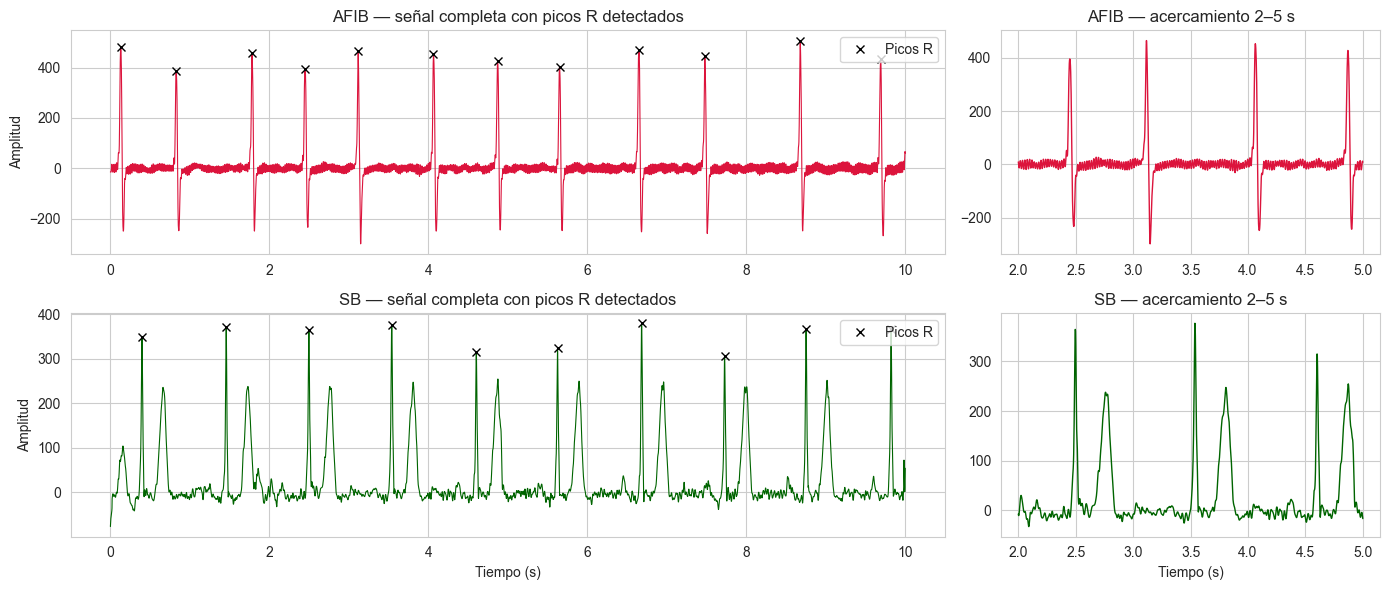

In [11]:
# Picos R detectados sobre cada señal y acercamiento de 3 s para observar la morfología (onda P / ondas f)
fig, axs = plt.subplots(2, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [3, 1.3]})

for fila, (t, ecg, picos, nombre, color) in enumerate([
        (t_afib, ecg_afib, picos_afib, "AFIB", "crimson"),
        (t_sb,   ecg_sb,   picos_sb,   "SB",   "darkgreen")]):
    axs[fila, 0].plot(t, ecg, color=color, lw=0.8)
    axs[fila, 0].plot(t[picos], ecg[picos], "kx", label="Picos R")
    axs[fila, 0].set_title(f"{nombre} — señal completa con picos R detectados")
    axs[fila, 0].set_ylabel("Amplitud")
    axs[fila, 0].legend(loc="upper right")

    ventana = (t >= 2) & (t <= 5)
    axs[fila, 1].plot(t[ventana], ecg[ventana], color=color, lw=1)
    axs[fila, 1].set_title(f"{nombre} — acercamiento 2–5 s")

axs[1, 0].set_xlabel("Tiempo (s)")
axs[1, 1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

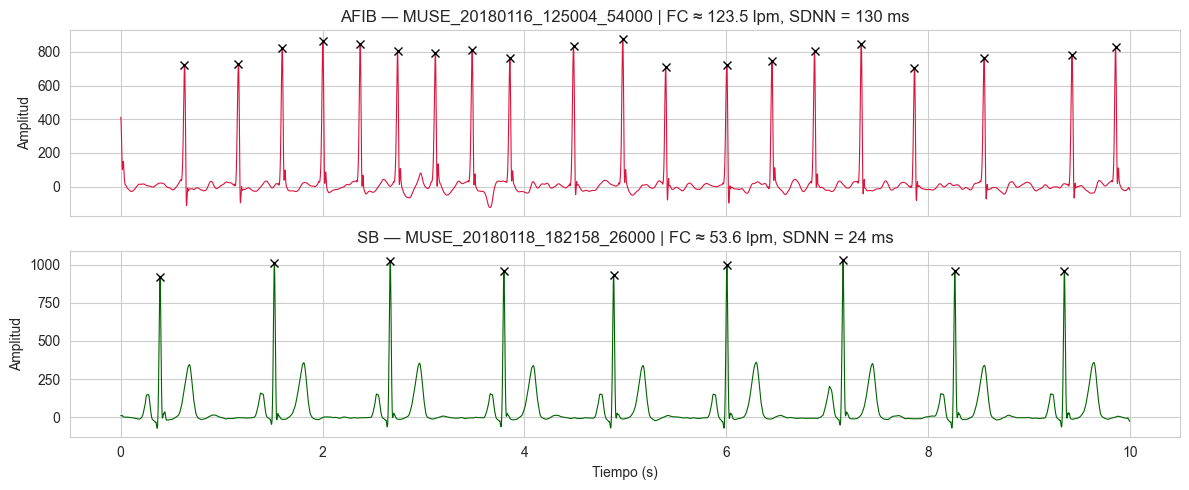

In [12]:
# Un segundo registro de cada ritmo, para no basar la caracterización en un solo paciente
archivo_afib2 = diagnosticos.loc[diagnosticos["Rhythm"] == "AFIB", "FileName"].sample(1, random_state=7).values[0]
archivo_sb2   = diagnosticos.loc[diagnosticos["Rhythm"] == "SB",   "FileName"].sample(1, random_state=7).values[0]

fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, archivo, nombre, color in [(axs[0], archivo_afib2, "AFIB", "crimson"),
                                   (axs[1], archivo_sb2,   "SB",   "darkgreen")]:
    t2, ecg2 = cargar_registro(archivo, derivacion="II")
    picos2 = detectar_picos_r(ecg2)
    ax.plot(t2, ecg2, color=color, lw=0.8)
    ax.plot(t2[picos2], ecg2[picos2], "kx")
    rr2 = np.diff(picos2) / FS
    ax.set_title(f"{nombre} — {archivo} | FC ≈ {60 / rr2.mean():.1f} lpm, SDNN = {rr2.std() * 1000:.0f} ms")
    ax.set_ylabel("Amplitud")
axs[1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

**Análisis:**

- *Morfología:* en los registros SB se reconoce en cada ciclo la secuencia onda P – complejo QRS – onda T, con una forma consistente latido a latido; en el segundo registro SB la onda P es claramente visible antes de cada QRS. En los registros AFIB no se observa una onda P organizada antes de cada QRS; en su lugar, la línea de base presenta oscilaciones rápidas y de baja amplitud (ondas f, visibles en el acercamiento de 2–5 s), que son el hallazgo morfológico más característico de la fibrilación auricular.
- *Amplitud:* las señales están en microvoltios (µV), con picos R entre aproximadamente 350 y 1000 µV en los cuatro registros. Las diferencias de amplitud entre registros dependen principalmente del paciente (contextura, posición de los electrodos) más que del tipo de ritmo.
- *Frecuencia cardiaca:* la FC estimada para el registro SB fue de 57.3 lpm, por debajo de 60 lpm como corresponde a la definición clínica de bradicardia; para el registro AFIB fue de 69.1 lpm. En ambos casos el valor estimado coincide con el reportado en `VentricularRate` (57 y 69 lpm), lo que valida el detector de picos R. En los segundos registros se obtuvo 53.6 lpm (SB) y 123.5 lpm (AFIB), lo que muestra que en AFIB la frecuencia ventricular puede ser normal o rápida según el paciente.
- *Regularidad:* la desviación estándar de los intervalos RR fue de 0.016 s (16 ms) en SB frente a 0.161 s (161 ms) en AFIB, es decir, unas 10 veces mayor. En SB los intervalos RR son prácticamente constantes (entre 1.02 y 1.07 s), mientras que en AFIB varían entre 0.67 y 1.20 s sin ningún patrón, reflejo del ritmo *irregularmente irregular* causado por la conducción auriculoventricular desorganizada. El mismo comportamiento se observa en el segundo registro de cada grupo (SDNN de 24 ms en SB frente a 130 ms en AFIB).

## 3. Análisis estadístico entre arritmias

Para comparar estadísticamente los dos grupos de arritmias (AFIB vs. SB) se calculan, para una muestra de sujetos de cada grupo, las siguientes características descriptivas sobre la derivación II de cada registro: media, desviación estándar, valor máximo, valor mínimo, frecuencia cardiaca estimada y valor RMS. Adicionalmente se calcula el **SDNN** (desviación estándar de los intervalos RR), que cuantifica la irregularidad del ritmo.

Se trabaja con una muestra de sujetos por grupo (en lugar de la totalidad de cada clase) por eficiencia computacional; el tamaño de muestra puede ampliarse cambiando `N_MUESTRA`.

In [13]:
def calcular_rms(señal):
    return np.sqrt(np.mean(np.asarray(señal) ** 2))

def intervalos_rr(señal, fs=FS):
    picos = detectar_picos_r(señal, fs)
    return np.diff(picos) / fs

def frecuencia_cardiaca(señal, fs=FS):
    rr = intervalos_rr(señal, fs)
    if len(rr) < 1:
        return np.nan
    return 60 / rr.mean()

def sdnn(señal, fs=FS):
    rr = intervalos_rr(señal, fs)
    if len(rr) < 2:
        return np.nan
    return rr.std() * 1000  # en milisegundos

def caracterizar_grupo(rhythm, n_muestra=30, derivacion="II", semilla=42):
    archivos = diagnosticos.loc[diagnosticos["Rhythm"] == rhythm, "FileName"]
    archivos = archivos.sample(min(n_muestra, len(archivos)), random_state=semilla)

    filas = []
    for nombre in archivos:
        try:
            _, señal = cargar_registro(nombre, derivacion=derivacion)
        except FileNotFoundError:
            continue
        # Algunos archivos de la base vienen con valores nulos o en cero: se descartan
        if np.isnan(señal).any() or np.all(señal == 0):
            continue
        filas.append({
            "FileName": nombre,
            "Rhythm": rhythm,
            "media": np.mean(señal),
            "std": np.std(señal),
            "max": np.max(señal),
            "min": np.min(señal),
            "rms": calcular_rms(señal),
            "fc_estimada": frecuencia_cardiaca(señal),
            "sdnn": sdnn(señal),
            "VentricularRate": diagnosticos.loc[diagnosticos["FileName"] == nombre, "VentricularRate"].values[0],
        })
    return pd.DataFrame(filas)

N_MUESTRA = 100
df_afib = caracterizar_grupo("AFIB", n_muestra=N_MUESTRA)
df_sb   = caracterizar_grupo("SB",   n_muestra=N_MUESTRA)

df_comparacion = pd.concat([df_afib, df_sb], ignore_index=True)
print("Registros válidos -> AFIB:", len(df_afib), "| SB:", len(df_sb))
df_comparacion.groupby("Rhythm")[["media", "std", "max", "min", "rms", "fc_estimada", "sdnn"]].describe().T

Registros válidos -> AFIB: 100 | SB: 100


Rhythm                    AFIB           SB
media       count   100.000000   100.000000
            mean     24.465752    34.005707
            std      25.224388    17.033646
            min     -96.726497   -17.004373
            25%       8.453426    22.889801
            50%      22.324428    32.050025
            75%      38.503797    45.171302
            max     104.440763    73.461031
std         count   100.000000   100.000000
            mean    128.863525   117.265516
            std      65.159452    37.704131
            min      19.866170    53.521494
            25%      83.045104    91.156565
            50%     117.735416   116.469746
            75%     157.476150   141.911686
            max     349.729761   223.705255
max         count   100.000000   100.000000
            mean    777.299300   844.264430
            std     399.540198   326.431573
            min     110.020000    96.053000
            25%     488.570000   605.652500
            50%     717.865000   849.695000
            75%     995.712500  1058.200000
            max    2203.100000  1530.600000
min         count   100.000000   100.000000
            mean   -321.750350  -200.550690
            std     334.664514   173.236451
            min   -2005.900000  -993.360000
            25%    -387.562500  -229.400000
            50%    -220.040000  -157.115000
            75%     -97.732250   -86.770000
            max     -41.660000   -31.391000
rms         count   100.000000   100.000000
            mean    132.391295   122.608651
            std      67.495828    39.814435
            min      19.866734    54.919956
            25%      84.229014    95.467265
            50%     119.682318   122.092749
            75%     161.382900   149.182485
            max     364.991477   232.497032
fc_estimada count    98.000000   100.000000
            mean     93.337750    55.273962
            std      27.609388     3.752595
            min      45.731707    43.509790
            25%      73.494355    52.545158
            50%      89.899254    56.655752
            75%     109.583215    58.432073
            max     161.323681    59.471366
sdnn        count    98.000000   100.000000
            mean    174.030157    32.848490
            std     174.713565    38.844589
            min      37.011166     4.408798
            25%     103.547711    15.124754
            50%     132.177065    23.243813
            75%     166.566384    32.350543
            max    1385.179396   280.203051

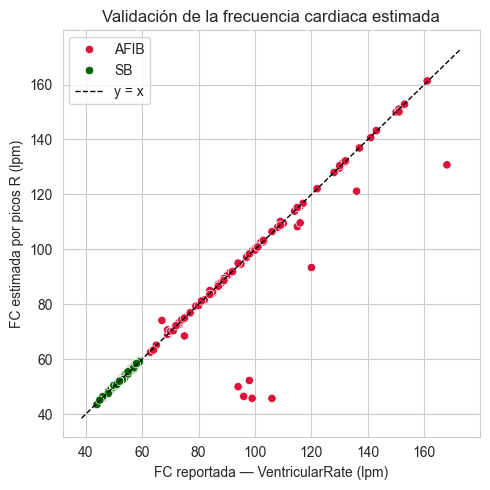

Correlación de Spearman: rho = 0.914 (p = 6.04e-79)
Error absoluto medio: 2.09 lpm | mediana: 0.30 lpm


In [14]:
# Validación del detector de picos R: FC estimada vs. FC reportada por el equipo (VentricularRate)
validos = df_comparacion.dropna(subset=["fc_estimada", "VentricularRate"])
rho, p_rho = spearmanr(validos["fc_estimada"], validos["VentricularRate"])
error_abs = (validos["fc_estimada"] - validos["VentricularRate"]).abs()

plt.figure(figsize=(5, 5))
sns.scatterplot(data=validos, x="VentricularRate", y="fc_estimada", hue="Rhythm",
                palette=["crimson", "darkgreen"])
lim = [validos[["VentricularRate", "fc_estimada"]].min().min() - 5,
       validos[["VentricularRate", "fc_estimada"]].max().max() + 5]
plt.plot(lim, lim, "k--", lw=1, label="y = x")
plt.xlabel("FC reportada — VentricularRate (lpm)")
plt.ylabel("FC estimada por picos R (lpm)")
plt.title("Validación de la frecuencia cardiaca estimada")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Correlación de Spearman: rho = {rho:.3f} (p = {p_rho:.3g})")
print(f"Error absoluto medio: {error_abs.mean():.2f} lpm | mediana: {error_abs.median():.2f} lpm")

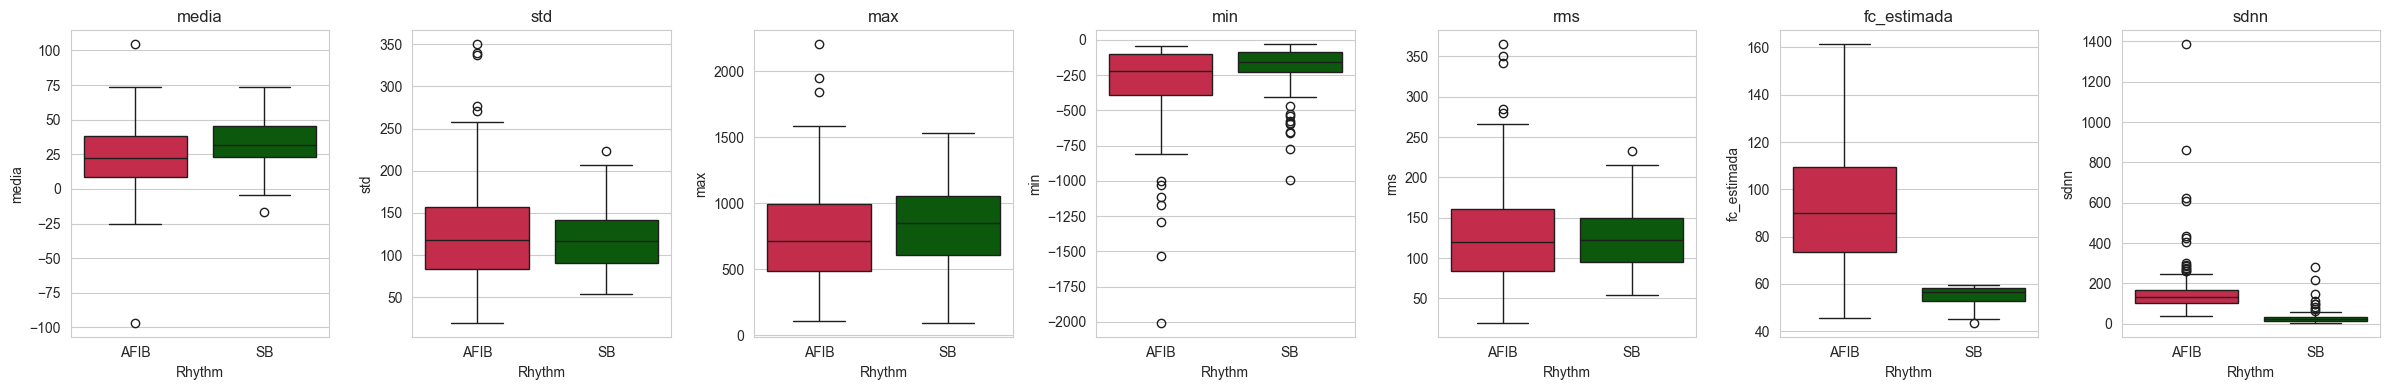

In [15]:
# Boxplots comparativos de las características descriptivas entre los dos grupos
variables = ["media", "std", "max", "min", "rms", "fc_estimada", "sdnn"]
fig, axs = plt.subplots(1, len(variables), figsize=(24, 4))

for ax, var in zip(axs, variables):
    sns.boxplot(data=df_comparacion, x="Rhythm", y=var, ax=ax, hue="Rhythm", legend=False,
                palette=["crimson", "darkgreen"])
    ax.set_title(var)

plt.tight_layout()
plt.show()

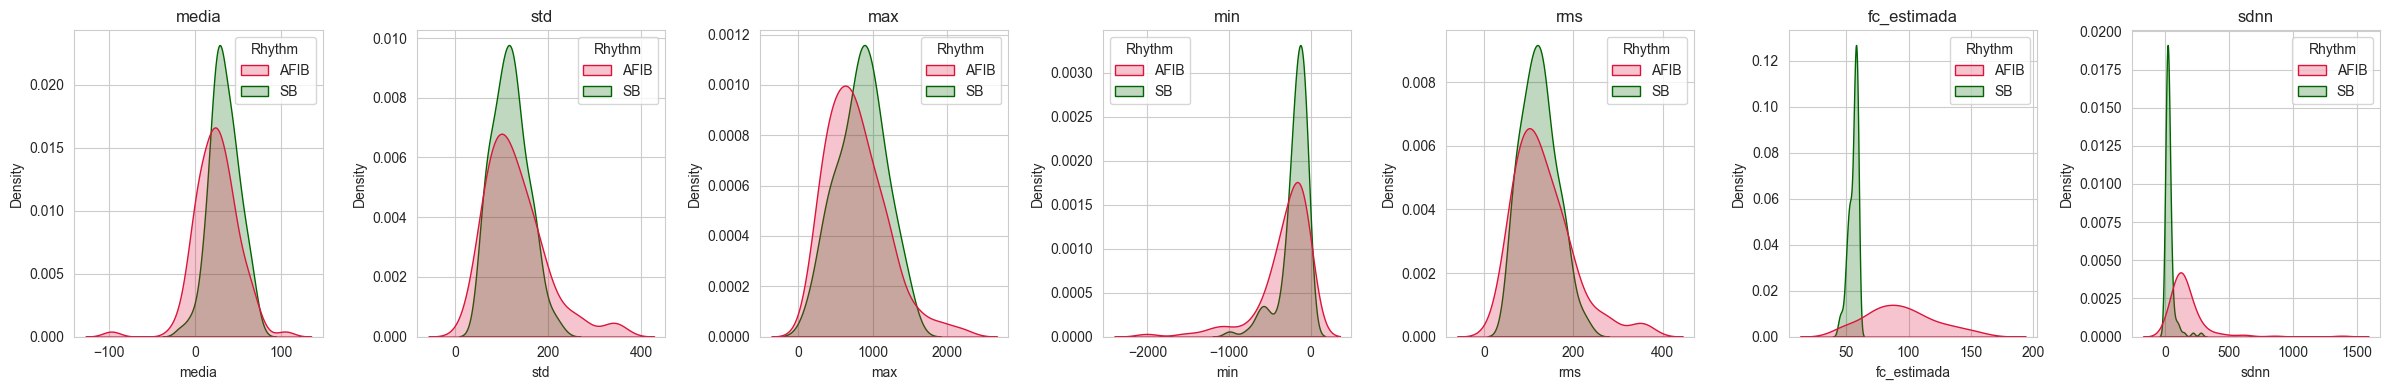

In [16]:
# Diagramas de densidad comparativos
fig, axs = plt.subplots(1, len(variables), figsize=(24, 4))

for ax, var in zip(axs, variables):
    sns.kdeplot(data=df_comparacion, x=var, hue="Rhythm", fill=True, ax=ax,
                palette=["crimson", "darkgreen"], common_norm=False)
    ax.set_title(var)

plt.tight_layout()
plt.show()

**Análisis descriptivo:** los boxplots y diagramas de densidad permiten comparar visualmente cómo se distribuye cada característica en los dos grupos. La variable con mayor interés clínico para diferenciar estos dos ritmos es la frecuencia cardiaca estimada (`fc_estimada`): el grupo SB se concentra en valores bajos y muy agrupados (mediana de 56.7 lpm, rango de 43.5 a 59.5 lpm, desviación estándar de 3.8 lpm), todos por debajo de 60 lpm, mientras que el grupo AFIB presenta valores más altos y mucho más dispersos (mediana de 89.9 lpm, rango de 45.7 a 161.3 lpm, desviación estándar de 27.6 lpm), ya que no está restringido a un rango de frecuencia por definición. El `sdnn` muestra la diferencia más marcada entre grupos: la mediana es de 132.2 ms en AFIB frente a 23.2 ms en SB, lo que refleja la irregularidad de los intervalos RR en la fibrilación auricular. (En 2 de los 100 registros AFIB no se detectaron suficientes picos R para estimar la FC y el SDNN, por lo que ese grupo quedó con 98 valores.)

En cuanto a la amplitud (en µV), `std` y `rms` se comportan de forma casi idéntica (medianas de 117.7 y 119.7 µV en AFIB, y 116.5 y 122.1 µV en SB): como la `media` de la señal es pequeña frente a su dispersión (medianas de 22.3 µV en AFIB y 32.1 µV en SB, un nivel DC residual del filtrado), se cumple RMS = √(std² + media²) ≈ std, por lo que ambas variables aportan prácticamente la misma información. Las medianas de amplitud son muy similares entre grupos, aunque el grupo AFIB presenta mayor dispersión (desviación estándar del RMS de 67.5 µV frente a 39.8 µV en SB) y valores mínimos más negativos (mediana de −220 µV frente a −157 µV).

### Formulación de la hipótesis

Se toma como variable de interés el **valor RMS** de la derivación II entre los dos grupos de arritmias (AFIB y SB):

- **Hipótesis nula (H₀):** no existe diferencia estadísticamente significativa en el valor RMS de la señal ECG entre los grupos AFIB y SB (las medias/distribuciones de ambos grupos son iguales).
- **Hipótesis alternativa (H₁):** existe una diferencia estadísticamente significativa en el valor RMS de la señal ECG entre los grupos AFIB y SB.

Se define un nivel de significancia **α = 0.05**.

In [17]:
rms_afib = df_comparacion.loc[df_comparacion["Rhythm"] == "AFIB", "rms"].dropna()
rms_sb   = df_comparacion.loc[df_comparacion["Rhythm"] == "SB",   "rms"].dropna()

alpha = 0.05

# 1) Normalidad (Shapiro-Wilk) en cada grupo
stat_norm_afib, p_norm_afib = shapiro(rms_afib)
stat_norm_sb,   p_norm_sb   = shapiro(rms_sb)

print(f"Shapiro-Wilk AFIB: estadístico={stat_norm_afib:.4f}, p-value={p_norm_afib:.4g}")
print(f"Shapiro-Wilk SB:   estadístico={stat_norm_sb:.4f}, p-value={p_norm_sb:.4g}")

normal_afib = p_norm_afib > alpha
normal_sb   = p_norm_sb > alpha
print("\n¿AFIB se distribuye normal?", normal_afib)
print("¿SB se distribuye normal?", normal_sb)


Shapiro-Wilk AFIB: estadístico=0.9085, p-value=3.624e-06
Shapiro-Wilk SB:   estadístico=0.9776, p-value=0.08679

¿AFIB se distribuye normal? False
¿SB se distribuye normal? True


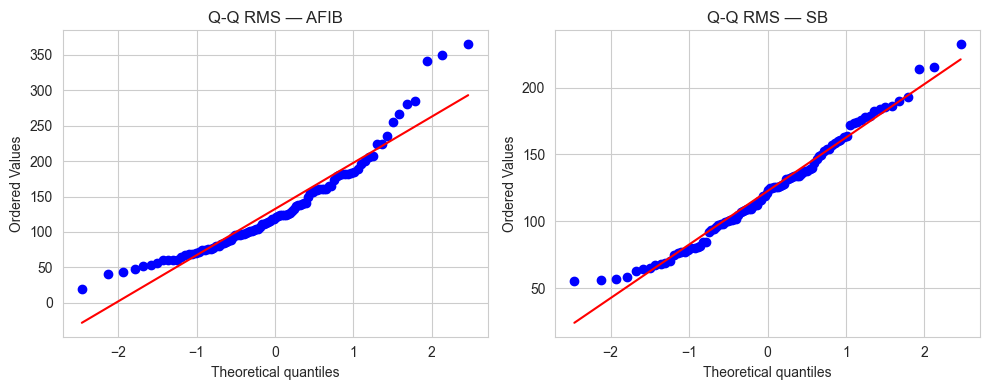

In [18]:
# Gráficos Q-Q como apoyo visual a la prueba de Shapiro-Wilk
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
probplot(rms_afib, dist="norm", plot=axs[0]); axs[0].set_title("Q-Q RMS — AFIB")
probplot(rms_sb,   dist="norm", plot=axs[1]); axs[1].set_title("Q-Q RMS — SB")
plt.tight_layout()
plt.show()

In [19]:
# 2) Homocedasticidad (prueba de Levene)
stat_levene, p_levene = levene(rms_afib, rms_sb)
print(f"Levene: estadístico={stat_levene:.4f}, p-value={p_levene:.4g}")

homocedastico = p_levene > alpha
print("¿Varianzas homogéneas (homocedasticidad)?", homocedastico)


Levene: estadístico=11.2143, p-value=0.0009716
¿Varianzas homogéneas (homocedasticidad)? False


In [20]:
# 3) Selección y ejecución de la prueba de hipótesis según se cumplan o no los supuestos
cumple_supuestos = normal_afib and normal_sb and homocedastico

if cumple_supuestos:
    prueba_usada = "t de Student para muestras independientes"
    estadistico, p_valor = ttest_ind(rms_afib, rms_sb, equal_var=True)
else:
    prueba_usada = "U de Mann-Whitney (no paramétrica)"
    estadistico, p_valor = mannwhitneyu(rms_afib, rms_sb, alternative="two-sided")

decision = "Se rechaza H0" if p_valor < alpha else "No se rechaza H0"

print("Prueba utilizada:", prueba_usada)
print(f"Estadístico de prueba: {estadistico:.4f}")
print(f"p-value: {p_valor:.4g}")
print("Decisión estadística:", decision)

# Tamaño del efecto: indica si la diferencia, además de significativa, es relevante
n1, n2 = len(rms_afib), len(rms_sb)
if cumple_supuestos:
    s_pooled = np.sqrt(((n1 - 1) * rms_afib.var() + (n2 - 1) * rms_sb.var()) / (n1 + n2 - 2))
    efecto = (rms_afib.mean() - rms_sb.mean()) / s_pooled
    print(f"Tamaño del efecto (d de Cohen): {efecto:.3f}")
else:
    z = (estadistico - n1 * n2 / 2) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    efecto = abs(z) / np.sqrt(n1 + n2)
    print(f"Tamaño del efecto (r = |Z|/√N): {efecto:.3f}  (≈0.1 pequeño, ≈0.3 mediano, ≥0.5 grande)")

Prueba utilizada: U de Mann-Whitney (no paramétrica)
Estadístico de prueba: 5068.0000
p-value: 0.869
Decisión estadística: No se rechaza H0
Tamaño del efecto (r = |Z|/√N): 0.012  (≈0.1 pequeño, ≈0.3 mediano, ≥0.5 grande)


**Interpretación:** si no se cumplen los supuestos de normalidad y/o homocedasticidad, se aplica la alternativa no paramétrica de Mann-Whitney, que no exige normalidad y compara si una de las dos distribuciones tiende a producir valores más altos que la otra. En esta muestra, la prueba de Shapiro-Wilk rechazó la normalidad del RMS en el grupo AFIB (p = 3.6×10⁻⁶), pero no en el grupo SB (p = 0.087), lo que coincide con los gráficos Q-Q: los puntos de AFIB se alejan de la recta en las colas, reflejando una distribución asimétrica con valores altos atípicos. La prueba de Levene (p = 0.00097) indicó además que las varianzas no son homogéneas, ya que la amplitud es más dispersa en AFIB. Al no cumplirse los supuestos, se utilizó la prueba U de Mann-Whitney, que dio U = 5068, p = 0.869 y un tamaño del efecto r = 0.012 (prácticamente nulo). Como p > α = 0.05, **no se rechaza H₀**.

Es decir, no hay evidencia de que el valor RMS de la derivación II difiera entre pacientes con fibrilación auricular y pacientes con bradicardia sinusal: las medianas son casi iguales (119.7 µV frente a 122.1 µV). Esto es coherente con la fisiología: el RMS mide la amplitud global de la señal, que depende principalmente de cada paciente (contextura, posición de los electrodos, eje eléctrico) y no del mecanismo del ritmo. La diferencia entre AFIB y SB reside en la frecuencia y en la regularidad temporal de los latidos (variabilidad de los intervalos RR). Por eso a continuación se repite el mismo procedimiento para todas las características.

### Comparación de todas las características

Se repite el mismo procedimiento (Shapiro-Wilk → Levene → t de Student o U de Mann-Whitney) para cada una de las características calculadas. Como se realizan 7 pruebas simultáneamente, además de α = 0.05 se reporta la decisión con la **corrección de Bonferroni** (α/7), que controla la probabilidad de obtener algún falso positivo al hacer múltiples comparaciones.

In [21]:
variables_prueba = ["media", "std", "max", "min", "rms", "fc_estimada", "sdnn"]
alpha_bonf = alpha / len(variables_prueba)

filas = []
for var in variables_prueba:
    a = df_comparacion.loc[df_comparacion["Rhythm"] == "AFIB", var].dropna()
    b = df_comparacion.loc[df_comparacion["Rhythm"] == "SB",   var].dropna()
    p_na, p_nb = shapiro(a).pvalue, shapiro(b).pvalue
    p_lev = levene(a, b).pvalue
    n1, n2 = len(a), len(b)

    if p_na > alpha and p_nb > alpha and p_lev > alpha:
        prueba = "t de Student"
        est, p = ttest_ind(a, b, equal_var=True)
        s_p = np.sqrt(((n1 - 1) * a.var() + (n2 - 1) * b.var()) / (n1 + n2 - 2))
        efecto_txt = f"d = {(a.mean() - b.mean()) / s_p:.2f}"
    else:
        prueba = "U de Mann-Whitney"
        est, p = mannwhitneyu(a, b, alternative="two-sided")
        z = (est - n1 * n2 / 2) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
        efecto_txt = f"r = {abs(z) / np.sqrt(n1 + n2):.2f}"

    filas.append({
        "Variable": var,
        "Mediana AFIB": round(a.median(), 4),
        "Mediana SB": round(b.median(), 4),
        "Shapiro AFIB (p)": p_na,
        "Shapiro SB (p)": p_nb,
        "Levene (p)": p_lev,
        "Prueba": prueba,
        "Estadístico": round(est, 3),
        "p-valor": p,
        "Tamaño efecto": efecto_txt,
        "Decisión (α=0.05)": "Se rechaza H0" if p < alpha else "No se rechaza H0",
        f"Decisión Bonferroni (α={alpha_bonf:.4f})": "Se rechaza H0" if p < alpha_bonf else "No se rechaza H0",
    })

tabla_pruebas = pd.DataFrame(filas)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
tabla_pruebas

,Variable,Mediana AFIB,Mediana SB,Shapiro AFIB (p),Shapiro SB (p),Levene (p),Prueba,Estadístico,p-valor,Tamaño efecto,Decisión (α=0.05),Decisión Bonferroni (α=0.0071)
0,media,22.32,32.05,0.0001225,0.6656,0.01865,U de Mann-Whitney,3642,0.0009102,r = 0.23,Se rechaza H0,Se rechaza H0
1,std,117.7,116.5,3.405e-06,0.08991,0.0005879,U de Mann-Whitney,5203,0.6208,r = 0.04,No se rechaza H0,No se rechaza H0
2,max,717.9,849.7,0.0002471,0.5429,0.1623,U de Mann-Whitney,4206,0.05237,r = 0.14,No se rechaza H0,No se rechaza H0
3,min,-220,-157.1,3.23e-12,3.993e-11,0.001676,U de Mann-Whitney,3876,0.006048,r = 0.19,Se rechaza H0,Se rechaza H0
4,rms,119.7,122.1,3.624e-06,0.08679,0.0009716,U de Mann-Whitney,5068,0.869,r = 0.01,No se rechaza H0,No se rechaza H0
5,fc_estimada,89.9,56.66,0.06533,4.506e-07,1.503e-22,U de Mann-Whitney,8850,1.16e-22,r = 0.70,Se rechaza H0,Se rechaza H0
6,sdnn,132.2,23.24,4.254e-16,3.135e-16,0.0002551,U de Mann-Whitney,9430,2.722e-29,r = 0.80,Se rechaza H0,Se rechaza H0


**Análisis:** en ninguna de las 7 características se cumplieron simultáneamente la normalidad en ambos grupos y la homocedasticidad, por lo que en todos los casos se utilizó la prueba U de Mann-Whitney.

- **Variables de ritmo:** `fc_estimada` (p = 1.2×10⁻²²) y `sdnn` (p = 2.7×10⁻²⁹) presentan diferencias altamente significativas entre AFIB y SB, con tamaños de efecto grandes (r = 0.70 y r = 0.80), y se mantienen significativas con la corrección de Bonferroni. Son, además, los efectos más grandes de toda la tabla. Esto es coherente con la definición clínica de cada arritmia: SB se define por una frecuencia baja con ritmo regular, y AFIB por un ritmo irregularmente irregular.
- **Variables de amplitud:** `std` (p = 0.62), `rms` (p = 0.87) y `max` (p = 0.052) no muestran diferencias significativas. El `min` sí resultó significativo (p = 0.006, se mantiene con Bonferroni), pero con un tamaño de efecto pequeño (r = 0.19): el grupo AFIB tiene mínimos más negativos (mediana de −220 µV frente a −157 µV).
- **Media:** aunque es significativa (p = 0.0009, r = 0.23, efecto pequeño), no tiene interpretación fisiológica directa: corresponde al nivel DC residual de la señal filtrada, que resultó algo mayor en SB (32.1 µV) que en AFIB (22.3 µV).

En conclusión, las características que realmente separan ambos grupos son las relacionadas con el ritmo, mientras que las de amplitud dependen más de cada paciente que del tipo de arritmia.

## 4. Interpretación de los resultados (resumen del reporte estadístico)

La siguiente celda genera automáticamente la tabla de reporte para la hipótesis principal (valor RMS), con los valores obtenidos en la sección 3. Los resultados para las demás características se encuentran en `tabla_pruebas`.

In [22]:
reporte = pd.DataFrame({
    "Elemento": ["Prueba utilizada", "Hipótesis nula (H₀)", "Hipótesis alternativa (H₁)",
                 "Nivel de significancia (α)", "Estadístico de prueba", "p-valor",
                 "Tamaño del efecto", "Decisión estadística"],
    "Valor": [prueba_usada,
              "No hay diferencia en el valor RMS entre AFIB y SB",
              "Sí hay diferencia en el valor RMS entre AFIB y SB",
              alpha, f"{estadistico:.4f}", f"{p_valor:.4g}", f"{efecto:.3f}", decision],
})
pd.set_option("display.max_colwidth", None)
reporte

,Elemento,Valor
0,Prueba utilizada,U de Mann-Whitney (no paramétrica)
1,Hipótesis nula (H₀),No hay diferencia en el valor RMS entre AFIB y SB
2,Hipótesis alternativa (H₁),Sí hay diferencia en el valor RMS entre AFIB y SB
3,Nivel de significancia (α),0.05
4,Estadístico de prueba,5068.0000
5,p-valor,0.869
6,Tamaño del efecto,0.012
7,Decisión estadística,No se rechaza H0


**Interpretación en contexto ECG/arritmias:** no se encontró diferencia significativa en el valor RMS entre AFIB y SB (p = 0.869, r = 0.012). La energía global de la señal ECG depende en gran medida de las características de cada paciente y no permite diferenciar estos dos ritmos. Las variables que sí caracterizan a cada arritmia son la frecuencia cardiaca y la regularidad de los intervalos RR (SDNN), que según `tabla_pruebas` presentan diferencias significativas y con los mayores tamaños de efecto entre ambos grupos. Esto coincide con la forma en que se diagnostican clínicamente: la bradicardia sinusal por su frecuencia baja y la fibrilación auricular por la irregularidad del ritmo y la ausencia de onda P.

## Conclusiones

- La base de datos ChapmanECG constituye un recurso robusto para el estudio estadístico de arritmias, con 10 646 pacientes y 11 tipos de ritmo cardiaco, aunque con una distribución de clases muy desbalanceada (SB y SR concentran más de la mitad de los registros, mientras que ritmos como AVNRT, AVRT y SAAWR están representados por menos de 20 pacientes cada uno).
- La comparación visual entre un registro de fibrilación auricular (AFIB) y uno de bradicardia sinusal (SB) permite ilustrar cómo dos arritmias con implicaciones clínicas muy distintas —una por irregularidad del ritmo, otra por lentitud del mismo— se manifiestan de forma diferente en la señal ECG, particularmente en la regularidad de los intervalos RR y en la morfología de la onda P.
- El análisis estadístico comparativo, siguiendo el procedimiento de verificación de supuestos (normalidad con Shapiro-Wilk, homocedasticidad con Levene) antes de decidir entre una prueba t o una prueba de Mann-Whitney, es el mismo enfoque metodológico utilizado en la primera parte de esta práctica sobre estacionariedad. En esta muestra, ninguna de las 7 características cumplió simultáneamente los supuestos de normalidad y homocedasticidad, por lo que en todos los casos se utilizó la prueba no paramétrica de Mann-Whitney.
- Las características relacionadas con el ritmo (frecuencia cardiaca y SDNN) son las que mejor diferencian estadísticamente AFIB de SB, mientras que las características de amplitud dependen más de cada paciente y resultan poco informativas: la hipótesis principal sobre el valor RMS no se rechazó (p = 0.869), y solo el mínimo mostró una diferencia significativa, con un efecto pequeño. La frecuencia cardiaca estimada a partir de los picos R coincidió con la reportada en `VentricularRate` (correlación de Spearman ρ = 0.91, error absoluto mediano de 0.30 lpm y medio de 2.09 lpm)
- Quedaría como trabajo adicional extender este análisis a los 11 ritmos disponibles (por ejemplo, mediante ANOVA o Kruskal-Wallis para más de dos grupos) y explorar otras derivaciones además de la II, así como incorporar otras variables ya presentes en `Diagnostics.xlsx` (como `QRSDuration` o `QTInterval`).

## Referencias

[1] J. Zheng, J. Zhang, S. Danioko, H. Yao, H. Guo, and C. Rakovski, "A 12-lead electrocardiogram database for arrhythmia research covering more than 10,000 patients," *Scientific Data*, vol. 7, no. 48, 2020. [En línea]. Disponible: https://doi.org/10.1038/s41597-020-0386-x

[2] Colección de datos ChapmanECG en figshare. [En línea]. Disponible: https://figshare.com/collections/ChapmanECG/4560497

[3] B. R. R. Boaretto, A. Andreani, S. R. Lopes, T. L. Prado, and E. E. N. Macau, "The use of entropy of recurrence microstates and artificial intelligence to detect cardiac arrhythmia in ECG records," *Chaos: An Interdisciplinary Journal of Nonlinear Science*, vol. 34, 043108, 2024. [En línea]. Disponible: https://doi.org/10.1063/5.0193967

[4] J. Amat Rodrigo, "T-test con Python", CienciaDeDatos.net, Dic. 2021. [En línea]. Disponible: https://cienciadedatos.net/documentos/pystats10-t-test-python.html

[5] Pruebas para homocedasticidad, cienciadedatos.net. [En línea]. Disponible: https://www.cienciadedatos.net/documentos/pystats07-testhomocedasticidad-heterocedasticidad-python.html

[6] Prueba U de Mann-Whitney. [En línea]. Disponible: https://jmyao17.github.io/Statistics/Nonparametric_Statistical_Significance_Tests.html